# LSTM Price Forecasting Model Training

This notebook generates a synthetic dataset of historical prices for 22 crops, trains an LSTM model to forecast future prices, and saves the artifacts for the ML microservice.

In [1]:
import numpy as np
import pandas as pd
import json
import os
import joblib
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

## 1. Generate Synthetic Historical Data

We'll base our synthetic data on the average current market prices defined in our backend (`marketPrices.js`). We'll simulate 5 years (60 months) of data with some seasonal fluctuation and random noise.

In [2]:
# Average Market Prices per Ton (USD) from marketPrices.js
base_prices = {
    'rice': 450, 'maize': 300, 'chickpea': 800, 'kidneybeans': 1200,
    'pigeonpeas': 900, 'mothbeans': 1100, 'mungbean': 1300, 'blackgram': 1000,
    'lentil': 1100, 'pomegranate': 1500, 'banana': 600, 'mango': 1200,
    'grapes': 2000, 'watermelon': 400, 'muskmelon': 500, 'apple': 1800,
    'orange': 1400, 'papaya': 800, 'coconut': 3500, 'cotton': 1600,
    'jute': 700, 'coffee': 4000
}

months = 60 # 5 years
seq_length = 5 # use 5 sequence length to predict 6th

def generate_crop_prices(base_price, months):
    prices = []
    for i in range(months):
        # Add some seasonality (sine wave) and random noise
        seasonality = 0.1 * base_price * np.sin(2 * np.pi * i / 12) 
        noise = np.random.normal(0, 0.05 * base_price)
        # Overall gentle trend (inflation)
        trend = base_price * (i / months) * 0.15
        
        price = base_price + seasonality + noise + trend
        prices.append(max(price, 50)) # Ensure positive prices
    return prices

data = []
crop_history_dict = {}

for crop, base_price in base_prices.items():
    prices = generate_crop_prices(base_price, months)
    
    # Save the last `seq_length` points for production inference context
    crop_history_dict[crop] = prices[-seq_length:]
    
    for i in range(months):
        data.append({
            'crop': crop,
            'month_idx': i,
            'price': prices[i]
        })

df = pd.DataFrame(data)

print("Sample of synthetic data:")
print(df.head(10))

Sample of synthetic data:
   crop  month_idx       price
0  rice          0  421.357992
1  rice          1  486.235946
2  rice          2  493.687403
3  rice          3  519.307892
4  rice          4  483.067949
5  rice          5  450.868849
6  rice          6  438.531758
7  rice          7  394.280737
8  rice          8  394.770506
9  rice          9  395.435158


## 2. Prepare Data for LSTM (Sequence Formatting & Scaling)

We'll scale all prices across the board using a single `MinMaxScaler`.

In [3]:
scaler = MinMaxScaler()
df['scaled_price'] = scaler.fit_transform(df[['price']])

X, y = [], []

# Build sequences per crop
for crop in df['crop'].unique():
    crop_data = df[df['crop'] == crop]['scaled_price'].values
    for i in range(len(crop_data) - seq_length):
        X.append(crop_data[i : i + seq_length])
        y.append(crop_data[i + seq_length])

X = np.array(X)
y = np.array(y)

# Reshape X for LSTM [samples, time steps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1210, 5, 1)
y shape: (1210,)


## 3. Build & Train the LSTM Model

In [4]:
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(seq_length, 1)))
model.add(Dense(1))
model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

history = model.fit(X, y, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

c:\Users\ronad\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0066 - val_loss: 0.0041
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 7.0846e-04 - val_loss: 0.0032
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.3124e-04 - val_loss: 0.0036
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 5.3275e-04 - val_loss: 0.0028
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4.6753e-04 - val_loss: 0.0030
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.6524e-04 - val_loss: 0.0034
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.5918e-04 - val_loss: 0.0029
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.6765e-04 - val_loss: 0.0027
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.7164e-04 - val_loss: 0.0024
Epoch 10/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.4101e-04 - val_loss: 0.0028
Epoch 11/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.5824e-04 - val_loss: 0.0026
Epoch 12/100


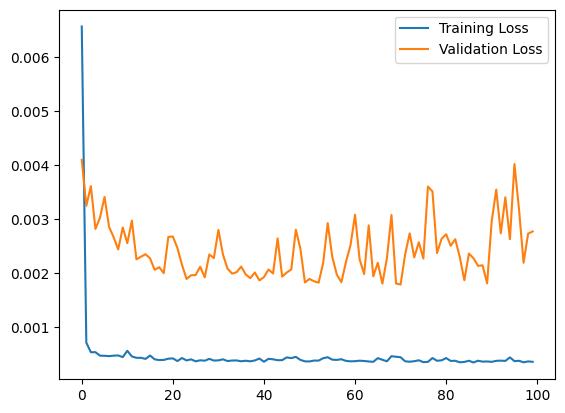

In [5]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

## 4. Export the artifacts

In [ ]:
MODELS_DIR = '../ml/models'
os.makedirs(MODELS_DIR, exist_ok=True)

# Save the model weights/architecture
model.save(os.path.join(MODELS_DIR, 'lstm_price_model.h5'))

# Save the scaler
joblib.dump(scaler, os.path.join(MODELS_DIR, 'price_scaler.pkl'))

# Save the historical synthetic price dictionary (used to form the sequence at runtime)
with open(os.path.join(MODELS_DIR, 'crop_price_history.json'), 'w') as f:
    json.dump(crop_history_dict, f)

print("✅ All ML Artifacts successfully saved to ml/models/")

✅ All ML Artifacts successfully saved to ml/models/


: 